# Team Game Logs — Pearson Correlation EDA (2024–25)

**Objetivo:** explorar correlaciones de Pearson entre todas las features numéricas útiles y los objetivos `WL_NUM` (derivado de `WL`) y `PLUS_MINUS`, además de una matriz de correlación entre features.

**Notas:** no se guardan ficheros; las visualizaciones utilizan la configuración por defecto de Matplotlib.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display


In [38]:
parquet_path = "/Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00c_final/2024-25/teamgamelogs_by_game.parquet"

try:
    df = pd.read_parquet(parquet_path, engine="pyarrow")
except ImportError as exc:
    raise ImportError("Se requiere pyarrow para leer el archivo parquet. Instale el paquete pyarrow e intente de nuevo.") from exc

print(f"Dataset shape: {df.shape}")
df.head(3)


Dataset shape: (2639, 128)


,SEASON_YEAR,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,AVAILABLE_FLAG,season,game_id,endpoint
0,2024-25,1610612737,ATL,Atlanta Hawks,0022400001,2024-11-12T00:00:00,ATL @ BOS,W,48.0,50,...,3529,1990,1318,3939,1340,2008,1.0,2024-25,0022400001,teamgamelogs_by_game
1,2024-25,1610612738,BOS,Boston Celtics,0022400001,2024-11-12T00:00:00,BOS vs. ATL,L,48.0,38,...,1551,256,147,2469,1437,2092,1.0,2024-25,0022400001,teamgamelogs_by_game
2,2024-25,1610612748,MIA,Miami Heat,0022400002,2024-11-12T00:00:00,MIA @ DET,L,53.0,47,...,2919,1265,3206,1661,927,2176,1.0,2024-25,0022400002,teamgamelogs_by_game


## Información de columnas y valores nulos

Se muestran los tipos de datos y el porcentaje de valores nulos por columna (máximo 30 columnas con más nulos). No se realizan imputaciones en esta etapa. Para cada cálculo de correlación se aplicará `dropna()` únicamente sobre las columnas implicadas, minimizando sesgos por registros incompletos.

In [39]:
if "GAME_DATE" in df.columns:
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"], errors="coerce")

df.info()

null_summary = (
    pd.DataFrame({
        "null_count": df.isna().sum(),
        "null_pct": df.isna().mean() * 100,
    })
    .sort_values(by=["null_pct", "null_count"], ascending=[False, False])
    .head(30)
)
null_summary


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2639 entries, 0 to 2638
Columns: 128 entries, SEASON_YEAR to endpoint
dtypes: datetime64[ns](1), float64(75), int64(42), object(8), string(2)
memory usage: 2.6+ MB


,null_count,null_pct
PCT_AST_2PM,189,7.161804
PCT_AST_3PM,189,7.161804
PCT_AST_FGM,189,7.161804
PCT_UAST_2PM,189,7.161804
PCT_UAST_3PM,189,7.161804
PCT_UAST_FGM,189,7.161804
PCT_FGA_2PT,189,7.161804
PCT_FGA_3PT,189,7.161804
PCT_PTS_2PT,189,7.161804
PCT_PTS_2PT_MR,189,7.161804


In [40]:
# 1. Verificar la columna WL
wl_col = df.get("WL")
print(f"Valores únicos en WL: {df['WL'].unique() if wl_col is not None else 'COLUMNA NO EXISTE'}")

if wl_col is not None:
    df["WL_NUM"] = (
        wl_col.astype(str)
        .str.strip()
        .str.upper()
        .map({"W": 1, "L": 0, "NAN": np.nan})  # Manejar nulos explícitamente
    )
    print(f"Distribución WL_NUM:\n{df['WL_NUM'].value_counts(dropna=False)}")
else:
    df["WL_NUM"] = np.nan

# 2. Diagnóstico de exclusiones
exclude_columns = {
    "SEASON_YEAR", "TEAM_ID", "TEAM_ABBREVIATION", "TEAM_NAME",
    "GAME_ID", "GAME_DATE", "MATCHUP", "WL", "WL_NUM",
    "endpoint", "season", "game_id", "AVAILABLE_FLAG"
}

rank_exclusions = {col for col in df.columns if col.endswith("_RANK")}
all_exclusions = exclude_columns.union(rank_exclusions)
print(f"\nColumnas excluidas: {len(all_exclusions)}")

# 3. Análisis detallado por columna
candidate_cols = [col for col in df.columns if col not in all_exclusions]
print(f"\nCandidatas iniciales: {len(candidate_cols)}")

valid_features = []
problematic_cols = []

for col in candidate_cols:
    s = df[col]

    # Verificar si es constante o todo nulo
    if s.isna().all():
        problematic_cols.append((col, "Todo nulo"))
        continue

    if s.nunique(dropna=True) <= 1:
        problematic_cols.append((col, "Constante"))
        continue

    # Conversión numérica robusta
    try:
        if s.dtype == 'bool':
            s_num = s.astype('int64')
        else:
            s_num = pd.to_numeric(s, errors='coerce')

        # Verificar calidad después de conversión
        n_nulls = s_num.isna().sum()
        n_unique = s_num.nunique(dropna=True)

        if n_unique > 1 and n_nulls < len(s):  # Aceptar hasta columnas con 90% nulos
            valid_features.append(col)
        else:
            problematic_cols.append((col, f"{n_unique} únicos, {n_nulls} nulos"))

    except Exception as e:
        problematic_cols.append((col, f"Error: {str(e)}"))

# 4. Resultados detallados
print(f"\n=== RESULTADOS ===")
print(f"Features válidas: {len(valid_features)}")
print(f"Columnas problemáticas: {len(problematic_cols)}")

print(f"\nPrimeras 20 válidas:")
print(valid_features[:20])

if problematic_cols:
    print(f"\nPrimeras 10 problemáticas:")
    for col, reason in problematic_cols[:10]:
        print(f"  {col}: {reason}")

# 5. Análisis de tipos de datos
print(f"\nDistribución de tipos en candidatas:")
print(df[candidate_cols].dtypes.value_counts())

Valores únicos en WL: ['W' 'L']
Distribución WL_NUM:
WL_NUM
1.0    1321
0.0    1318
Name: count, dtype: int64

Columnas excluidas: 39

Candidatas iniciales: 90

=== RESULTADOS ===
Features válidas: 90
Columnas problemáticas: 0

Primeras 20 válidas:
['MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD']

Distribución de tipos en candidatas:
float64    74
int64      16
Name: count, dtype: int64



=== ANÁLISIS PARA WL_NUM ===
Features disponibles: 90
Filas totales: 2639
Filas con target no nulo: 2639
Filas después de procesamiento: 2639

Correlaciones calculadas: 90

Estadísticas de correlación para WL_NUM:
Correlación máxima: 0.797
Correlación mínima: -0.378
Correlación promedio (abs): 0.142

Top 15 correlaciones positivas:


,pearson_correlation
PLUS_MINUS,0.797178
NET_RATING,0.578033
E_NET_RATING,0.578033
PTS,0.448718
FG_PCT,0.425404
FGM,0.375623
E_OFF_RATING,0.372405
OFF_RATING,0.372405
FG3_PCT,0.343937
DREB,0.330258


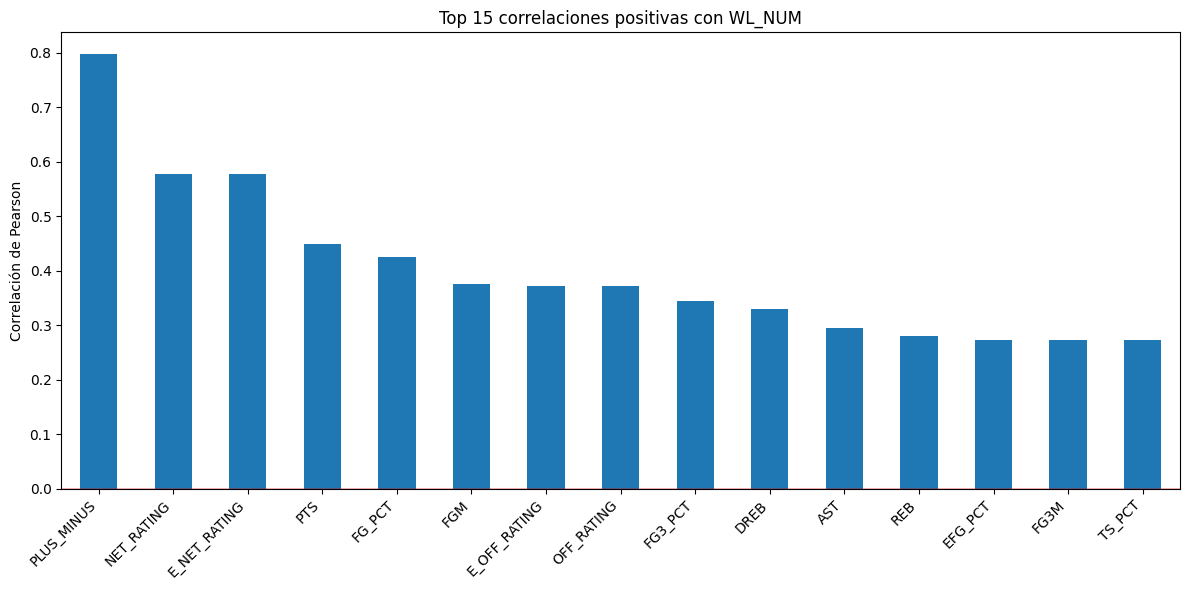


Top 10 correlaciones negativas:


,pearson_correlation
E_DEF_RATING,-0.378151
DEF_RATING,-0.378151
OPP_EFG_PCT,-0.340238
OPP_PTS_OFF_TOV,-0.219675
OPP_PTS_FB,-0.178600
TO,-0.163821
TOV,-0.146345
BLKA,-0.145141
OPP_PTS_PAINT,-0.141038
OPP_OREB_PCT,-0.114907


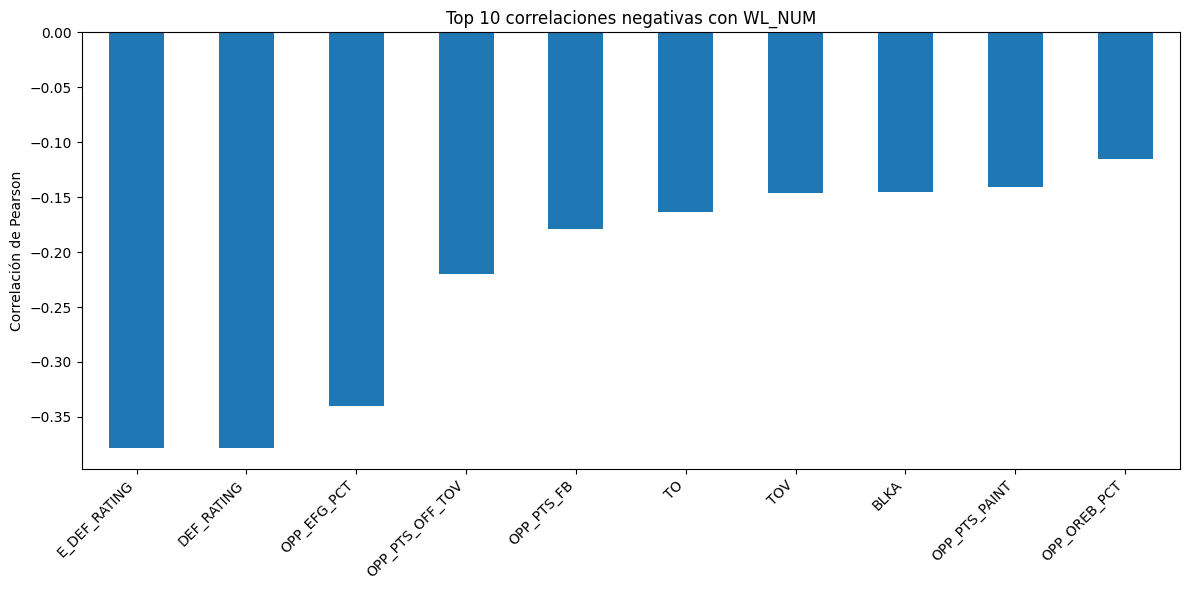


Información de nulos original:
Features con nulos: 68
Top 10 features con más nulos:
PCT_UAST_3PM       189
PCT_FGA_2PT        189
PCT_FGA_3PT        189
PCT_UAST_FGM       189
PCT_PTS_PAINT      189
PCT_PTS_3PT        189
PCT_PTS_FT         189
PCT_PTS_OFF_TOV    189
PCT_AST_3PM        189
PCT_AST_FGM        189
dtype: int64

=== ANÁLISIS PARA PLUS_MINUS ===
Features disponibles: 89
Filas totales: 2639
Filas con target no nulo: 2639
Filas después de procesamiento: 2639

Correlaciones calculadas: 89

Estadísticas de correlación para PLUS_MINUS:
Correlación máxima: 0.780
Correlación mínima: -0.516
Correlación promedio (abs): 0.175

Top 15 correlaciones positivas:


,pearson_correlation
NET_RATING,0.780221
E_NET_RATING,0.780221
PTS,0.563993
FG_PCT,0.530941
FGM,0.505768
OFF_RATING,0.497490
E_OFF_RATING,0.497490
FG3_PCT,0.424883
AST,0.395525
DREB,0.391854


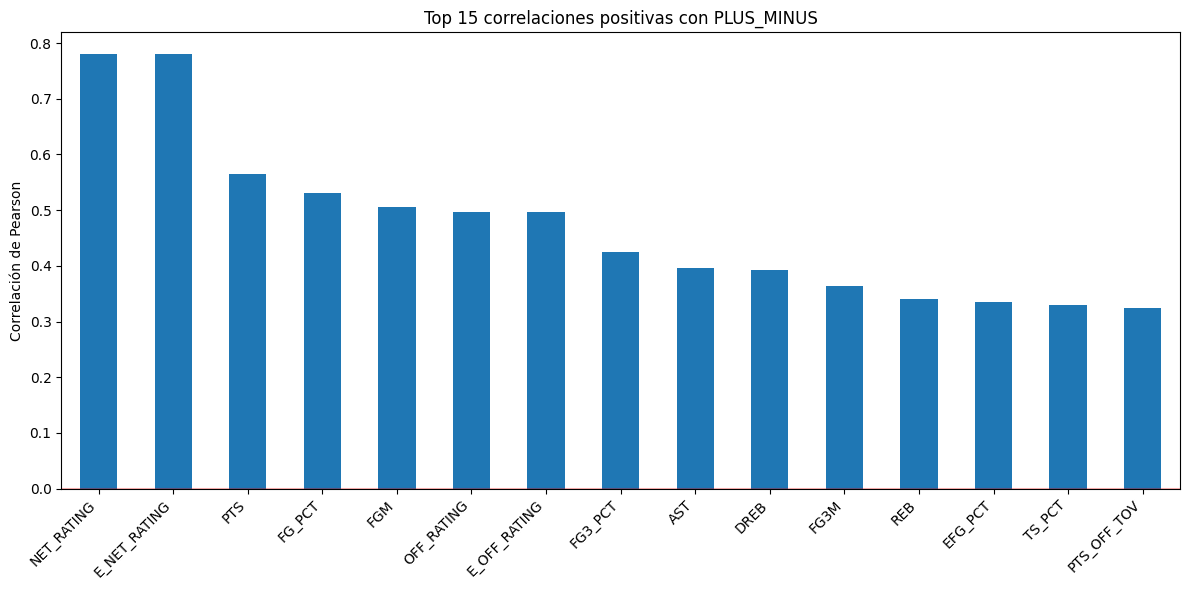


Top 10 correlaciones negativas:


,pearson_correlation
DEF_RATING,-0.515604
E_DEF_RATING,-0.515604
OPP_EFG_PCT,-0.455120
OPP_PTS_OFF_TOV,-0.302498
OPP_PTS_FB,-0.256912
TO,-0.217879
OPP_PTS_PAINT,-0.217435
TOV,-0.197263
OPP_OREB_PCT,-0.153078
BLKA,-0.150681


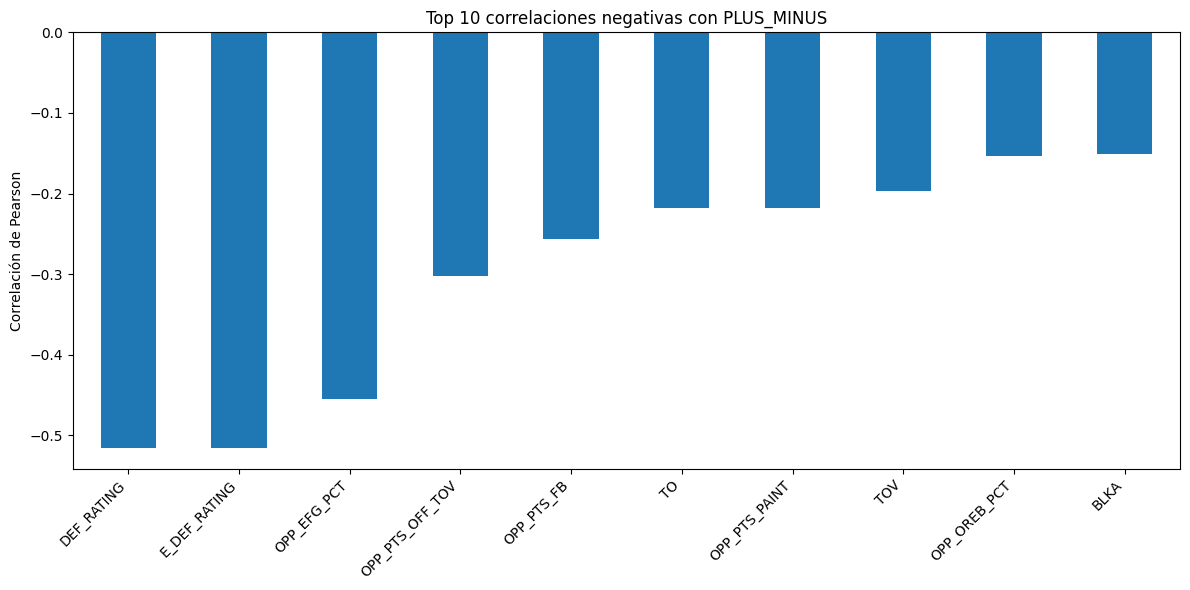


Información de nulos original:
Features con nulos: 68
Top 10 features con más nulos:
PCT_UAST_3PM       189
PCT_FGA_2PT        189
PCT_FGA_3PT        189
PCT_UAST_FGM       189
PCT_PTS_PAINT      189
PCT_PTS_3PT        189
PCT_PTS_FT         189
PCT_PTS_OFF_TOV    189
PCT_AST_3PM        189
PCT_AST_FGM        189
dtype: int64

=== ANÁLISIS PARA PTS ===
Features disponibles: 89
Filas totales: 2639
Filas con target no nulo: 2639
Filas después de procesamiento: 2639

Correlaciones calculadas: 89

Estadísticas de correlación para PTS:
Correlación máxima: 0.891
Correlación mínima: -0.233
Correlación promedio (abs): 0.180

Top 15 correlaciones positivas:


,pearson_correlation
FGM,0.890636
FG_PCT,0.723215
AST,0.680573
E_OFF_RATING,0.656005
OFF_RATING,0.656005
FG3M,0.569135
FG3_PCT,0.567208
PLUS_MINUS,0.563993
EFG_PCT,0.477167
TS_PCT,0.476634


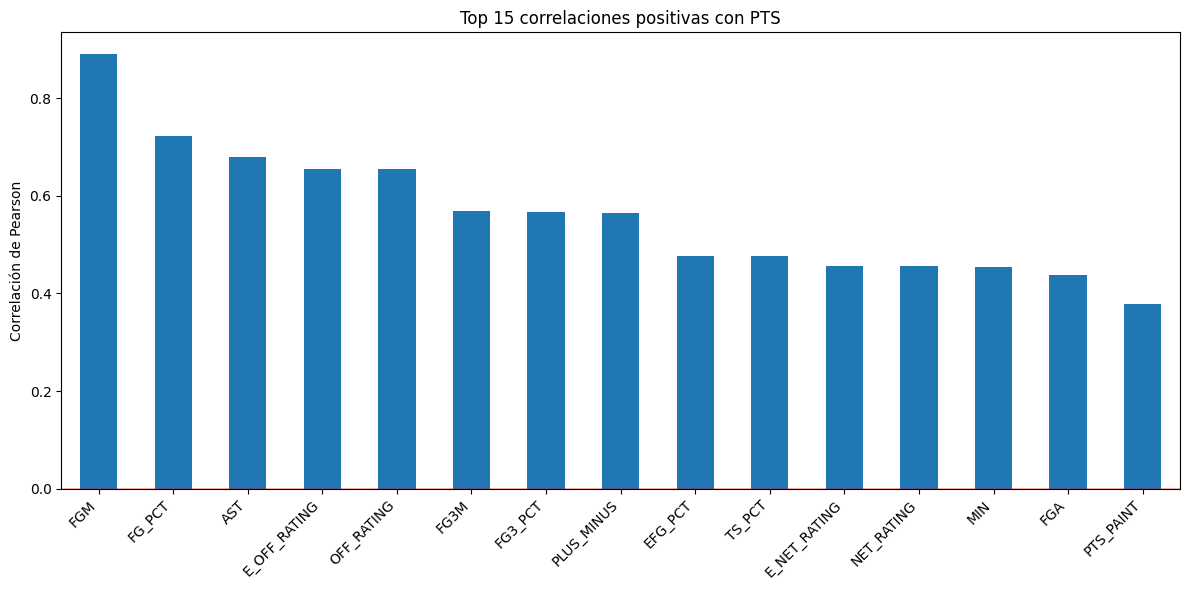


Top 5 correlaciones negativas:


,pearson_correlation
TOV,-0.232689
TM_TOV_PCT,-0.179291
TO,-0.172611
BLKA,-0.155484
OPP_PTS_OFF_TOV,-0.103538


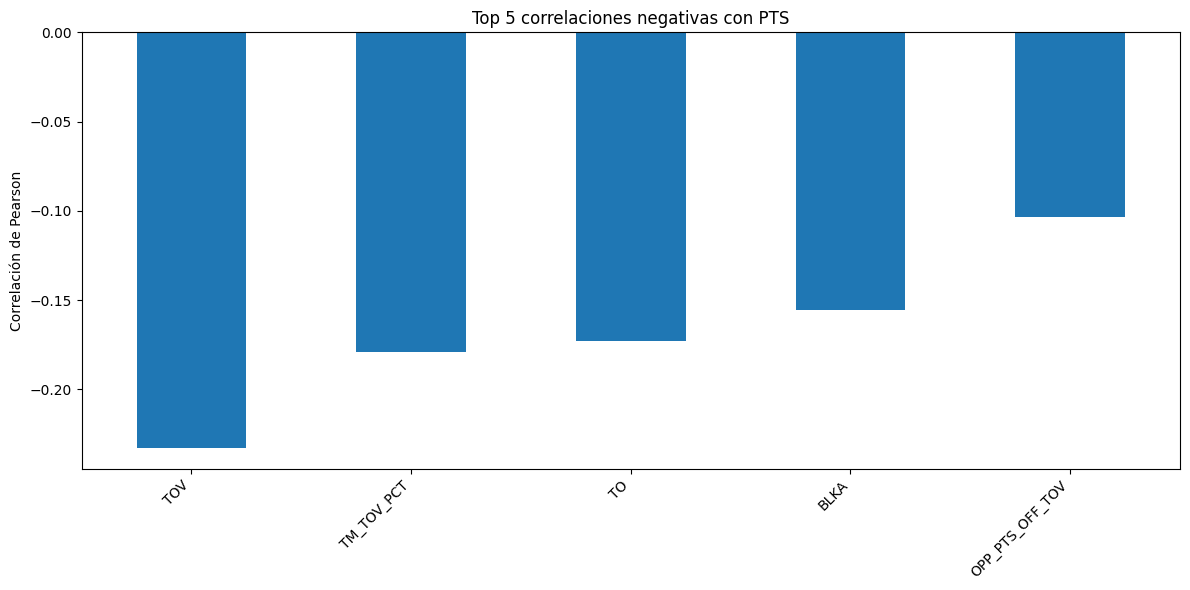


Información de nulos original:
Features con nulos: 68
Top 10 features con más nulos:
PCT_UAST_3PM       189
PCT_FGA_2PT        189
PCT_FGA_3PT        189
PCT_UAST_FGM       189
PCT_PTS_PAINT      189
PCT_PTS_3PT        189
PCT_PTS_FT         189
PCT_PTS_OFF_TOV    189
PCT_AST_3PM        189
PCT_AST_FGM        189
dtype: int64


In [43]:
targets = ["WL_NUM", "PLUS_MINUS", "PTS"]

for target in targets:
    if target not in df.columns:
        print(f"Objetivo '{target}' no encontrado. Se omite el análisis de correlación.")
        continue

    available_features = [feat for feat in valid_features if feat != target]
    if not available_features:
        print(f"No hay features válidas disponibles para correlacionar con {target}.")
        continue

    print(f"\n=== ANÁLISIS PARA {target} ===")
    print(f"Features disponibles: {len(available_features)}")

    # 1. Diagnóstico inicial de nulos por columna
    subset_df = df[available_features + [target]].copy()

    print(f"Filas totales: {len(subset_df)}")
    print(f"Filas con target no nulo: {subset_df[target].notna().sum()}")

    # 2. Estrategia mejorada para manejar nulos
    # Opción A: Imputar medianas en lugar de eliminar filas
    from sklearn.impute import SimpleImputer
    import numpy as np

    # Separar features y target
    X = subset_df[available_features]
    y = subset_df[target]

    # Identificar filas donde el target no es nulo
    valid_target_mask = y.notna()

    if valid_target_mask.sum() == 0:
        print(f"No hay valores válidos para el target {target}.")
        continue

    X_valid = X[valid_target_mask]
    y_valid = y[valid_target_mask]

    # Imputar nulos en features con la mediana
    imputer = SimpleImputer(strategy='median')
    X_imputed = imputer.fit_transform(X_valid)
    X_imputed = pd.DataFrame(X_imputed, columns=available_features, index=X_valid.index)

    # Combinar con target
    processed_df = pd.concat([X_imputed, y_valid], axis=1)

    print(f"Filas después de procesamiento: {len(processed_df)}")

    # 3. Calcular correlaciones
    corr_matrix = processed_df.corr(method="pearson")

    if target not in corr_matrix.columns:
        print(f"No se pudo calcular correlación para {target}")
        continue

    corr_series = corr_matrix[target].drop(labels=[target], errors='ignore')
    corr_series = corr_series.dropna().sort_values(ascending=False)

    print(f"\nCorrelaciones calculadas: {len(corr_series)}")

    if corr_series.empty:
        print(f"No se encontraron correlaciones para {target}")
        continue

    # 4. Filtrar correlaciones significativas
    significant_corr = corr_series[corr_series.abs() > 0.1]  # Umbral de significancia

    if significant_corr.empty:
        print("No hay correlaciones significativas (|r| > 0.1)")
        # Mostrar top correlaciones de todos modos
        significant_corr = corr_series.head(20)

    positive_corr = significant_corr[significant_corr > 0].head(15)
    negative_corr = significant_corr[significant_corr < 0].sort_values().head(10)

    # 5. Resultados mejorados
    print(f"\nEstadísticas de correlación para {target}:")
    print(f"Correlación máxima: {corr_series.max():.3f}")
    print(f"Correlación mínima: {corr_series.min():.3f}")
    print(f"Correlación promedio (abs): {corr_series.abs().mean():.3f}")

    if not positive_corr.empty:
        print(f"\nTop {len(positive_corr)} correlaciones positivas:")
        display(positive_corr.to_frame(name="pearson_correlation"))

        plt.figure(figsize=(max(12, len(positive_corr) * 0.8), 6))
        positive_corr.plot(kind="bar")
        plt.title(f"Top {len(positive_corr)} correlaciones positivas con {target}")
        plt.ylabel("Correlación de Pearson")
        plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print("No se encontraron correlaciones positivas significativas.")

    if not negative_corr.empty:
        print(f"\nTop {len(negative_corr)} correlaciones negativas:")
        display(negative_corr.to_frame(name="pearson_correlation"))

        plt.figure(figsize=(max(12, len(negative_corr) * 0.8), 6))
        negative_corr.plot(kind="bar")
        plt.title(f"Top {len(negative_corr)} correlaciones negativas con {target}")
        plt.ylabel("Correlación de Pearson")
        plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print("No se encontraron correlaciones negativas significativas.")

    # 6. Información adicional sobre datos faltantes
    print(f"\nInformación de nulos original:")
    null_info = subset_df[available_features].isnull().sum()
    high_null_cols = null_info[null_info > 0]
    if not high_null_cols.empty:
        print(f"Features con nulos: {len(high_null_cols)}")
        print("Top 10 features con más nulos:")
        print(high_null_cols.sort_values(ascending=False).head(10))

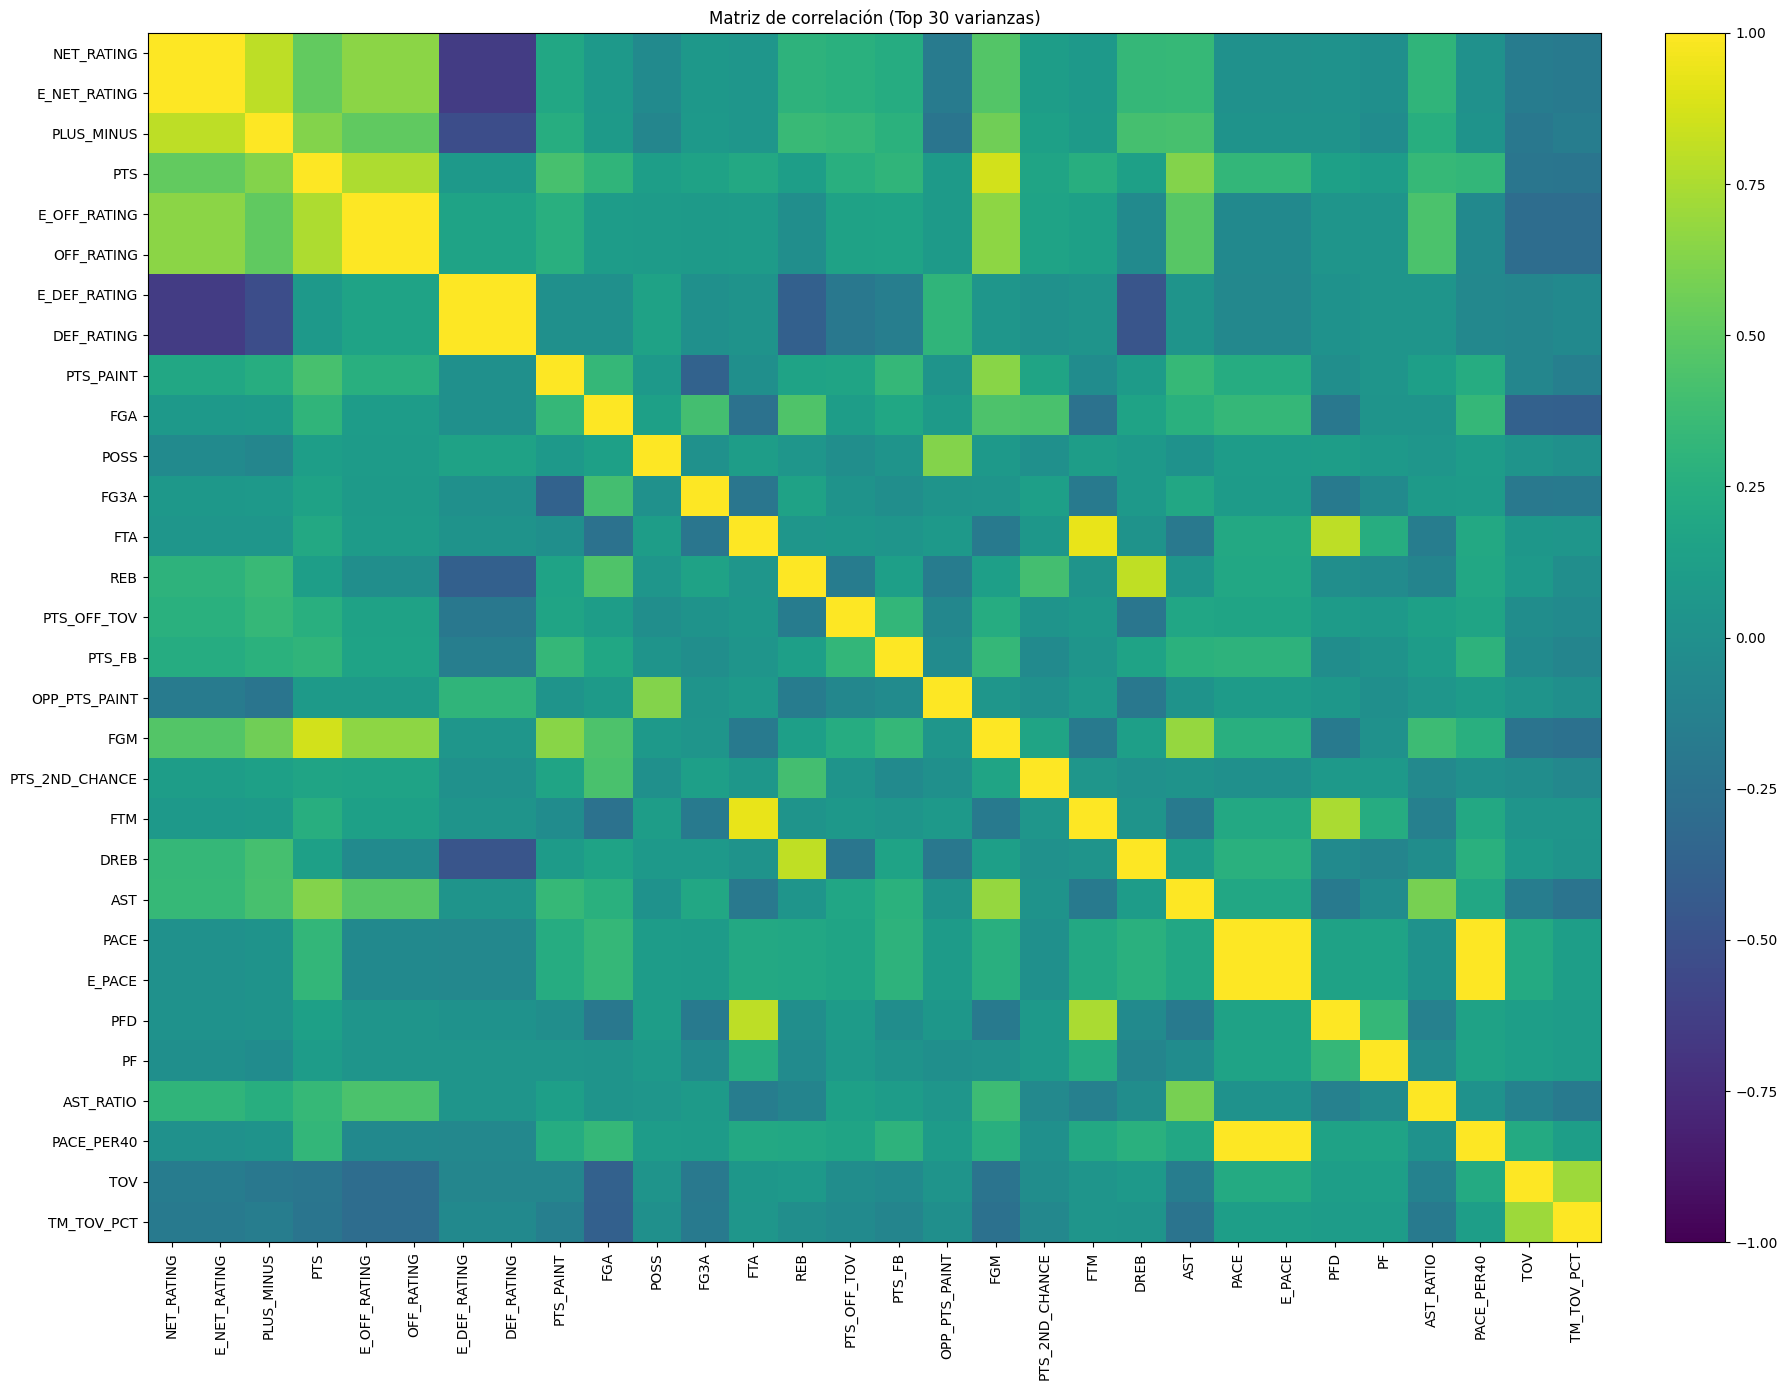

In [42]:
if valid_features:
    variances = df[valid_features].var(numeric_only=True).dropna().sort_values(ascending=False)
    top_var_features = variances.head(30).index.tolist()

    if top_var_features:
        feature_corr_df = df[top_var_features].dropna()
        if not feature_corr_df.empty and len(top_var_features) > 1:
            feature_corr_matrix = feature_corr_df.corr(method="pearson")

            plt.figure(figsize=(18, 14))
            im = plt.imshow(feature_corr_matrix, aspect="auto", vmin=-1, vmax=1)
            plt.colorbar(im, fraction=0.046, pad=0.04)
            plt.xticks(ticks=range(len(top_var_features)), labels=top_var_features, rotation=90)
            plt.yticks(ticks=range(len(top_var_features)), labels=top_var_features)
            plt.title("Matriz de correlación (Top 30 varianzas)")
            plt.tight_layout()
            plt.show()
        else:
            print("No hay suficientes datos completos para calcular la matriz de correlación de features.")
    else:
        print("No hay features con varianza suficiente para el análisis de correlación.")
else:
    print("No hay features válidas para analizar.")


## Nota

Si alguna correlación aparece como `NaN`, se debe a columnas constantes o sin observaciones válidas después del filtrado. Esto se mitiga excluyendo columnas sin variabilidad y aplicando `dropna()` por bloque de análisis.